**Nama** : Shinta Nuraini

**NPM** : 25083010021

**Kelas** : Analisis Numerik/ A083

# **Perhitungan Volume Kedua Lambung Perahu**

##**Tugas**
- Hitung volume kedua lambung kapal.
- Satu dash-kosong adalah 5+5 cm.
- Satu kotak grid = 45 cm.
- Anggap lantai kapal adalah datar (tidak ada keel) sehingga tampak depan
semuanya persegi panjang.
- Volume reserve buoyancy tidak usah dihitung.



## 1. Import Library dan Menampilkan Gambar dari PDF

Gambar desain kapal pada `perahu.pdf` diubah menjadi gambar (piksel) agar dapat ditampilkan dan diukur.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 65.0 MB/s eta 0:00:00


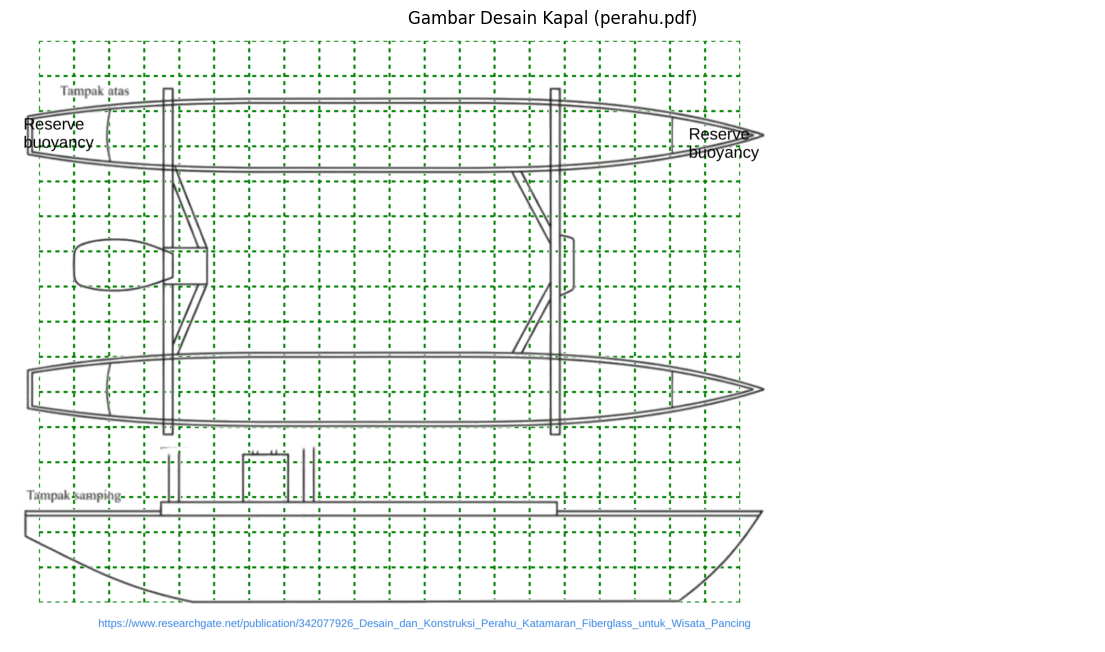

Ukuran gambar: 2382 x 1340 piksel


In [1]:
%pip install -q pymupdf

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import pymupdf as fitz
except ImportError:
    import fitz

NAMA_PDF = "perahu.pdf"
if not os.path.exists(NAMA_PDF):
    from google.colab import files          # hanya berjalan di Google Colab
    uploaded = files.upload()
    NAMA_PDF = next(iter(uploaded))

pdf = fitz.open(NAMA_PDF)
halaman = pdf[0]                             # halaman 1 berisi gambar kapal

gambar = halaman.get_pixmap(matrix=fitz.Matrix(3, 3), alpha=False)
gambar_array = np.frombuffer(gambar.samples, dtype=np.uint8).reshape(
    gambar.height, gambar.width, 3
)

plt.figure(figsize=(14, 8))
plt.imshow(gambar_array)
plt.title("Gambar Desain Kapal (perahu.pdf)")
plt.axis("off")
plt.show()

print("Ukuran gambar:", gambar.width, "x", gambar.height, "piksel")

## 2. Deteksi Grid dan Kalibrasi Skala

Garis grid hijau pada gambar dideteksi secara otomatis. Jarak antar garis grid (dalam piksel) dipakai untuk mengubah ukuran di gambar menjadi kotak, lalu menjadi cm dengan skala **1 kotak = 45 cm**.

In [2]:
# Deteksi garis grid hijau
R, G, B = (gambar_array[:, :, i].astype(int) for i in range(3))
hijau = (G > 100) & (R < 90) & (B < 90)

def cari_garis(proyeksi, rasio=0.25):
    idx = np.where(proyeksi > rasio * proyeksi.max())[0]
    kelompok = np.split(idx, np.where(np.diff(idx) > 3)[0] + 1)
    return np.array([k.mean() for k in kelompok if len(k) > 0])

x_garis = cari_garis(hijau.sum(axis=0))      # garis grid vertikal   (posisi x, piksel)
y_garis = cari_garis(hijau.sum(axis=1))      # garis grid horizontal (posisi y, piksel)

PX_PER_KOTAK = float(np.median(np.diff(x_garis)))
X0 = float(x_garis[0])                       # piksel x garis grid paling kiri (kotak ke-0)
Y0 = float(y_garis[0])                       # piksel y garis grid paling atas (kotak ke-0)

KOTAK_CM = 45                                # skala: 1 kotak = 45 cm

print(f"Jumlah garis vertikal   : {len(x_garis)}")
print(f"Jumlah garis horizontal : {len(y_garis)}")
print(f"Piksel per kotak        : {PX_PER_KOTAK:.2f}")
print(f"Origin grid (X0, Y0)    : ({X0:.1f}, {Y0:.1f}) piksel")
print(f"1 piksel = {KOTAK_CM / PX_PER_KOTAK:.4f} cm")

Jumlah garis vertikal   : 21
Jumlah garis horizontal : 17
Piksel per kotak        : 77.00
Origin grid (X0, Y0)    : (64.5, 22.5) piksel
1 piksel = 0.5844 cm


**Menentukan daerah perhitungan.**

Garis grid diberi nomor 0 sampai 20 dari kiri. Bagian *reserve buoyancy* berada di kiri garis grid ke-2 dan di kanan garis grid ke-18, sehingga tidak dihitung. Daerah yang dihitung adalah $x = 2$ sampai $x = 18$.

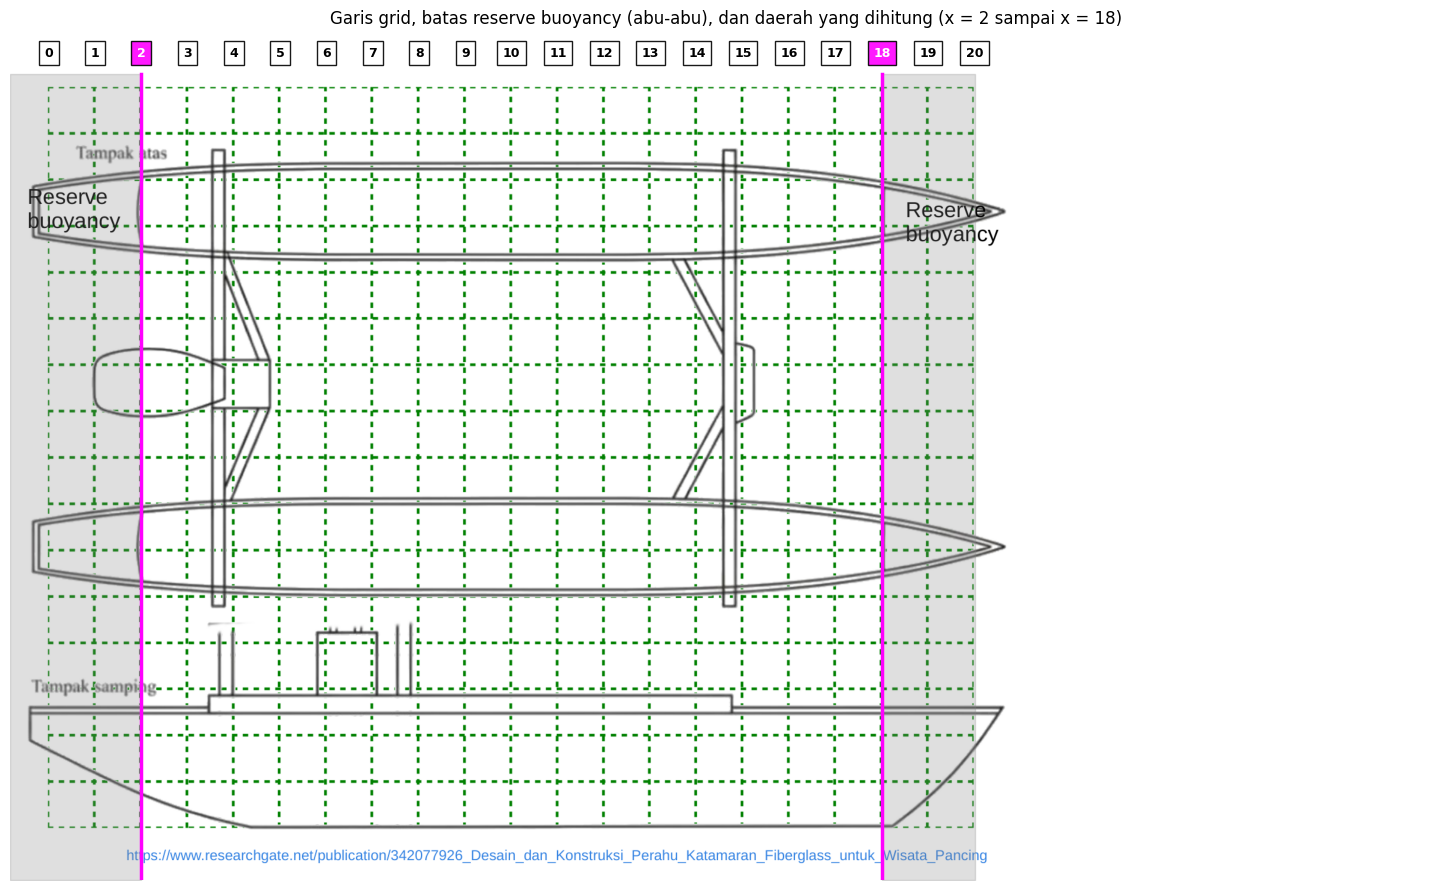

In [3]:
def px(X): return X0 + X * PX_PER_KOTAK      # kotak -> piksel (horizontal)
def py(Y): return Y0 + Y * PX_PER_KOTAK      # kotak -> piksel (vertikal)

X_AWAL, X_AKHIR = 2, 18                      # batas reserve buoyancy (kotak)

fig, ax = plt.subplots(figsize=(16, 9))
ax.imshow(gambar_array)

# nomor garis grid vertikal (garis ke-2 dan ke-18 ditandai magenta)
for i in range(len(x_garis)):
    batas = i in (X_AWAL, X_AKHIR)
    ax.text(px(i), -35, str(i), ha="center", va="center", fontsize=9, fontweight="bold",
            color="white" if batas else "black",
            bbox=dict(facecolor="magenta" if batas else "white", edgecolor="black", alpha=0.9))

# reserve buoyancy (tidak dihitung) diberi warna abu-abu
ax.fill_between([0, px(X_AWAL)], 0, gambar.height, color="gray", alpha=0.25)
ax.fill_between([px(X_AKHIR), px(len(x_garis) - 1)], 0, gambar.height, color="gray", alpha=0.25)
for xb in (X_AWAL, X_AKHIR):
    ax.plot([px(xb), px(xb)], [0, gambar.height], color="magenta", lw=2.5)

ax.set_xlim(0, gambar.width)
ax.set_ylim(gambar.height, -70)
ax.axis("off")
ax.set_title("Garis grid, batas reserve buoyancy (abu-abu), dan daerah yang dihitung (x = 2 sampai x = 18)")
plt.tight_layout()
plt.show()

## 3. Pembacaan Dimensi Lambung dan Verifikasi dengan Overlay

Pada setiap garis grid dari $x = 2$ sampai $x = 18$ (17 titik, 16 interval) dibaca:
- **lebar lambung** $w$ dari tampak atas, yaitu jarak antara tepi luar garis lambung bagian atas dan bagian bawah (kedua lambung dibaca masing-masing),
- **tinggi lambung** $d$ dari tampak samping, yaitu jarak dari garis deck (tepi atas) sampai dasar lambung.

In [5]:
# Posisi x (kotak): dari batas reserve buoyancy kiri (2) ke kanan (18)
x = np.arange(2, 19)                          # 2, 3, ..., 18  (17 titik, 16 interval)

# Lebar lambung ATAS dari TAMPAK ATAS (kotak)
w_atas = np.array([
    1.76, 1.94, 2.06, 2.10, 2.13, 2.13, 2.13, 2.13, 2.14,
    2.14, 2.14, 2.13, 2.09, 2.01, 1.86, 1.63, 1.34
])

# Lebar lambung BAWAH dari TAMPAK ATAS (kotak)
w_bawah = np.array([
    1.76, 1.92, 2.05, 2.10, 2.13, 2.13, 2.13, 2.13, 2.13,
    2.13, 2.13, 2.13, 2.09, 2.00, 1.85, 1.63, 1.34
])

# Tinggi lambung dari TAMPAK SAMPING (kotak), dari garis deck sampai dasar lambung
d = np.array([
    1.92, 2.28, 2.55, 2.64, 2.64, 2.63, 2.63, 2.63, 2.63,
    2.63, 2.62, 2.62, 2.62, 2.62, 2.62, 2.61, 2.61
])

# Posisi acuan pada gambar (kotak, diukur dari garis grid paling atas)
YC_ATAS  = 2.68     # garis tengah lambung atas  (tampak atas)
YC_BAWAH = 9.90     # garis tengah lambung bawah (tampak atas)
Y_DEK    = 13.35    # garis deck (tepi atas) pada tampak samping

assert len(x) == len(w_atas) == len(w_bawah) == len(d)
print("Jumlah titik =", len(x), "| jumlah interval =", len(x) - 1)

Jumlah titik = 17 | jumlah interval = 16


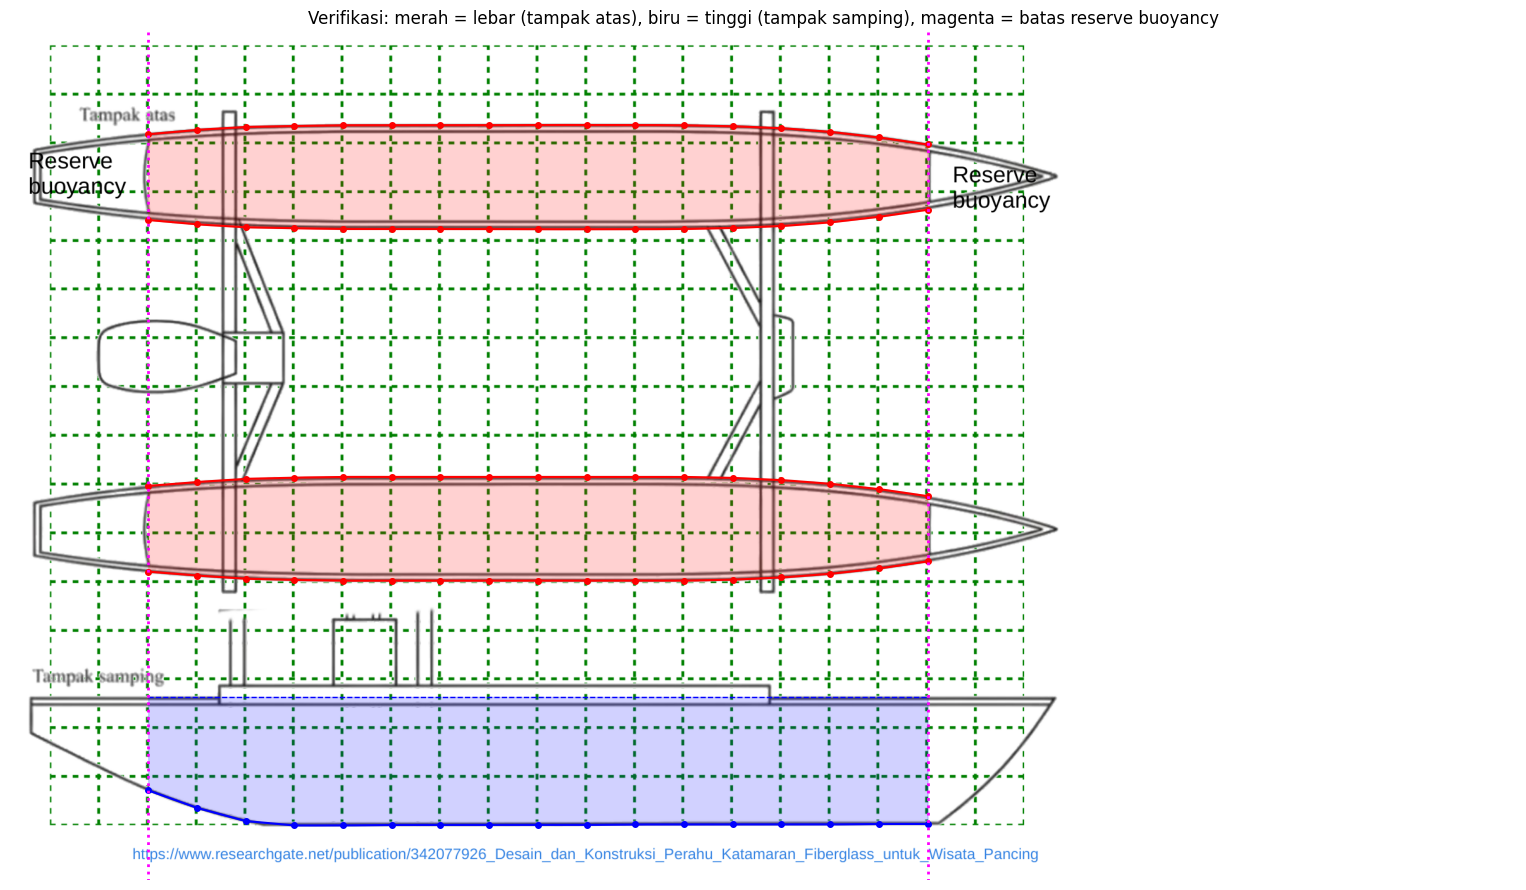

In [6]:
fx = np.linspace(x[0], x[-1], 300)

fig, ax = plt.subplots(figsize=(16, 9))
ax.imshow(gambar_array)

# Lebar lambung atas dan bawah (tampak atas): merah
for yc, w in ((YC_ATAS, w_atas), (YC_BAWAH, w_bawah)):
    wi = np.interp(fx, x, w)
    ax.fill_between(px(fx), py(yc - wi / 2), py(yc + wi / 2), color="red", alpha=0.18)
    ax.plot(px(fx), py(yc - wi / 2), "r-", lw=1.5)
    ax.plot(px(fx), py(yc + wi / 2), "r-", lw=1.5)
    ax.plot(px(x), py(yc - w / 2), "ro", ms=4)
    ax.plot(px(x), py(yc + w / 2), "ro", ms=4)

# Tinggi lambung (tampak samping): biru
di = np.interp(fx, x, d)
ax.fill_between(px(fx), py(Y_DEK), py(Y_DEK + di), color="blue", alpha=0.18)
ax.plot(px(fx), py(Y_DEK + di), "b-", lw=1.5)
ax.plot(px(x), py(Y_DEK + d), "bo", ms=4)
ax.plot(px(fx), py(Y_DEK + 0 * fx), "b--", lw=1)          # garis deck

# Batas reserve buoyancy
for xb in (X_AWAL, X_AKHIR):
    ax.plot([px(xb), px(xb)], [0, gambar.height], color="magenta", ls=":", lw=2)

ax.set_xlim(0, gambar.width)
ax.set_ylim(gambar.height, 0)
ax.axis("off")
ax.set_title("Verifikasi: merah = lebar (tampak atas), biru = tinggi (tampak samping), "
             "magenta = batas reserve buoyancy")
plt.tight_layout()
plt.show()

## 4. Perhitungan Volume

Karena tampak depan lambung berbentuk persegi panjang, luas penampang pada posisi $x$ adalah

$$A(x) = w(x) \cdot d(x)$$

Volume satu lambung diperoleh dengan mengintegrasikan luas penampang sepanjang lambung:

$$V = \int_{x_0}^{x_n} A(x)\,dx$$

Integral dihitung secara numerik dengan dua metode, dengan $h = 45$ cm sebagai jarak antar titik dan $n = 16$ sebagai jumlah interval:

$$V_{\text{trapesium}} = h\left[\frac{A_0 + A_n}{2} + \sum_{i=1}^{n-1} A_i\right]$$

$$V_{\text{Simpson 1/3}} = \frac{h}{3}\left[A_0 + A_n + 4\sum_{i\ \text{ganjil}} A_i + 2\sum_{i\ \text{genap}} A_i\right]$$

Simpson 1/3 dipakai sebagai metode utama (syaratnya: jarak titik seragam dan jumlah interval genap), sedangkan aturan trapesium dipakai sebagai pembanding. Kedua lambung dihitung secara terpisah, lalu dijumlahkan.

### 4.1 Luas penampang di setiap titik

In [7]:
# Konversi ke cm
x_cm = x * KOTAK_CM
w_atas_cm = w_atas * KOTAK_CM
w_bawah_cm = w_bawah * KOTAK_CM
d_cm = d * KOTAK_CM

# Luas penampang (tampak depan = persegi panjang)
A_atas = w_atas_cm * d_cm
A_bawah = w_bawah_cm * d_cm

tabel_penampang = pd.DataFrame({
    "No": np.arange(1, len(x) + 1),
    "x (kotak)": x,
    "x (cm)": x_cm,
    "w atas (cm)": w_atas_cm,
    "w bawah (cm)": w_bawah_cm,
    "d (cm)": d_cm,
    "A atas = w·d (cm²)": A_atas,
    "A bawah = w·d (cm²)": A_bawah,
})

print("TABEL 1. Tabel Penampang Lambung")
display(
    tabel_penampang.style
    .format({
        "x (kotak)": "{:.0f}", "x (cm)": "{:,.1f}",
        "w atas (cm)": "{:,.2f}", "w bawah (cm)": "{:,.2f}", "d (cm)": "{:,.2f}",
        "A atas = w·d (cm²)": "{:,.1f}", "A bawah = w·d (cm²)": "{:,.1f}",
    })
    .hide(axis="index")
)

TABEL 1. Tabel Penampang Lambung


No,x (kotak),x (cm),w atas (cm),w bawah (cm),d (cm),A atas = w·d (cm²),A bawah = w·d (cm²)
1,2,90.0,79.20,79.20,86.40,"6,842.9","6,842.9"
2,3,135.0,87.30,86.40,102.60,"8,957.0","8,864.6"
3,4,180.0,92.70,92.25,114.75,"10,637.3","10,585.7"
4,5,225.0,94.50,94.50,118.80,"11,226.6","11,226.6"
5,6,270.0,95.85,95.85,118.80,"11,387.0","11,387.0"
6,7,315.0,95.85,95.85,118.35,"11,343.8","11,343.8"
7,8,360.0,95.85,95.85,118.35,"11,343.8","11,343.8"
8,9,405.0,95.85,95.85,118.35,"11,343.8","11,343.8"
9,10,450.0,96.30,95.85,118.35,"11,397.1","11,343.8"
10,11,495.0,96.30,95.85,118.35,"11,397.1","11,343.8"


### 4.2 Integrasi numerik (trapesium dan Simpson 1/3)

In [8]:
h = KOTAK_CM                    # jarak antar titik (cm)
n = len(x) - 1                  # jumlah interval

print(f"Jarak antar titik h = {h} cm")
print(f"Jumlah titik        = {len(x)}")
print(f"Jumlah interval n   = {n}")
print(f"Panjang daerah hitung = n x h = {n * h} cm")
assert n % 2 == 0, "Simpson 1/3 membutuhkan jumlah interval genap"
print("n genap -> metode Simpson 1/3 dapat digunakan")

def trapesium(A, h):
    return h * (A[0] / 2 + np.sum(A[1:-1]) + A[-1] / 2)

def simpson_13(A, h):
    return h / 3 * (A[0] + A[-1] + 4 * np.sum(A[1:-1:2]) + 2 * np.sum(A[2:-1:2]))

# Volume tiap lambung (cm³)
V_trap_atas, V_trap_bawah = trapesium(A_atas, h), trapesium(A_bawah, h)
V_simp_atas, V_simp_bawah = simpson_13(A_atas, h), simpson_13(A_bawah, h)

# Volume kedua lambung (cm³)
V_trap = V_trap_atas + V_trap_bawah
V_simp = V_simp_atas + V_simp_bawah

tabel_volume = pd.DataFrame({
    "Metode": ["Trapesium", "Simpson 1/3"],
    "Lambung atas (cm³)": [V_trap_atas, V_simp_atas],
    "Lambung bawah (cm³)": [V_trap_bawah, V_simp_bawah],
    "Kedua lambung (cm³)": [V_trap, V_simp],
    "Kedua lambung (m³)": [V_trap / 1e6, V_simp / 1e6],
    "Kedua lambung (liter)": [V_trap / 1e3, V_simp / 1e3],
})

selisih_pct = abs(V_simp - V_trap) / V_trap * 100

print("\nTABEL 2. Hasil Perhitungan Volume")
display(
    tabel_volume.style
    .format({
        "Lambung atas (cm³)": "{:,.0f}", "Lambung bawah (cm³)": "{:,.0f}",
        "Kedua lambung (cm³)": "{:,.0f}", "Kedua lambung (m³)": "{:.4f}",
        "Kedua lambung (liter)": "{:,.1f}",
    })
    .hide(axis="index")
)
print(f"Selisih trapesium vs Simpson 1/3: {selisih_pct:.4f} %")

Jarak antar titik h = 45 cm
Jumlah titik        = 17
Jumlah interval n   = 16
Panjang daerah hitung = n x h = 720 cm
n genap -> metode Simpson 1/3 dapat digunakan

TABEL 2. Hasil Perhitungan Volume


Metode,Lambung atas (cm³),Lambung bawah (cm³),Kedua lambung (cm³),Kedua lambung (m³),Kedua lambung (liter)
Trapesium,"7,599,889","7,581,454","15,181,343",15.1813,"15,181.3"
Simpson 1/3,"7,612,036","7,593,786","15,205,822",15.2058,"15,205.8"


Selisih trapesium vs Simpson 1/3: 0.1612 %


### 4.3 Rincian volume tiap interval (metode trapesium)

In [9]:
dV_atas = (A_atas[:-1] + A_atas[1:]) / 2 * h
dV_bawah = (A_bawah[:-1] + A_bawah[1:]) / 2 * h

tabel_interval = pd.DataFrame({
    "Interval": [f"x{a} - x{b}" for a, b in zip(x[:-1], x[1:])],
    "A atas awal (cm²)": A_atas[:-1],
    "A atas akhir (cm²)": A_atas[1:],
    "ΔV atas (cm³)": dV_atas,
    "ΔV bawah (cm³)": dV_bawah,
})

display(tabel_interval.style.format("{:,.1f}", subset=tabel_interval.columns[1:]).hide(axis="index"))
print(f"Jumlah ΔV lambung atas  = {dV_atas.sum():,.2f} cm³")
print(f"Jumlah ΔV lambung bawah = {dV_bawah.sum():,.2f} cm³")

Interval,A atas awal (cm²),A atas akhir (cm²),ΔV atas (cm³),ΔV bawah (cm³)
x2 - x3,"6,842.9","8,957.0","355,496.8","353,419.2"
x3 - x4,"8,957.0","10,637.3","440,871.9","437,632.4"
x4 - x5,"10,637.3","11,226.6","491,938.3","490,776.5"
x5 - x6,"11,226.6","11,387.0","508,805.6","508,805.6"
x6 - x7,"11,387.0","11,343.8","511,443.6","511,443.6"
x7 - x8,"11,343.8","11,343.8","510,473.1","510,473.1"
x8 - x9,"11,343.8","11,343.8","510,473.1","510,473.1"
x9 - x10,"11,343.8","11,397.1","511,671.4","510,473.1"
x10 - x11,"11,397.1","11,397.1","512,869.7","510,473.1"
x11 - x12,"11,397.1","11,353.8","511,894.7","509,502.7"


Jumlah ΔV lambung atas  = 7,599,888.79 cm³
Jumlah ΔV lambung bawah = 7,581,454.20 cm³


### 4.4 Hasil akhir

In [10]:
# Hasil akhir memakai metode utama: Simpson 1/3
V_m3 = V_simp / 1e6                 # 1 m³ = 1.000.000 cm³
V_liter = V_simp / 1e3              # 1 liter = 1000 cm³

print("HASIL PERHITUNGAN")
print("===================================")
print(f"Skala                 = 1 kotak = {KOTAK_CM} cm")
print(f"Panjang lambung utama = {n * h} cm (x = {x[0]} sampai {x[-1]} kotak)")
print(f"Volume lambung atas   = {V_simp_atas:.2f} cm³")
print(f"Volume lambung bawah  = {V_simp_bawah:.2f} cm³")
print(f"Volume kedua lambung  = {V_simp:.2f} cm³")
print(f"Volume kedua lambung  = {V_m3:.6f} m³")
print(f"Volume kedua lambung  = {V_liter:.2f} liter")

HASIL PERHITUNGAN
Skala                 = 1 kotak = 45 cm
Panjang lambung utama = 720 cm (x = 2 sampai 18 kotak)
Volume lambung atas   = 7612035.75 cm³
Volume lambung bawah  = 7593786.45 cm³
Volume kedua lambung  = 15205822.20 cm³
Volume kedua lambung  = 15.205822 m³
Volume kedua lambung  = 15205.82 liter


## 5. Visualisasi Hasil

Grafik di bawah dibuat setelah perhitungan selesai: (kiri) lebar dan tinggi lambung sepanjang daerah yang dihitung, (kanan) luas penampang $A(x)$. Luas di bawah kurva $A(x)$ adalah volume lambung.

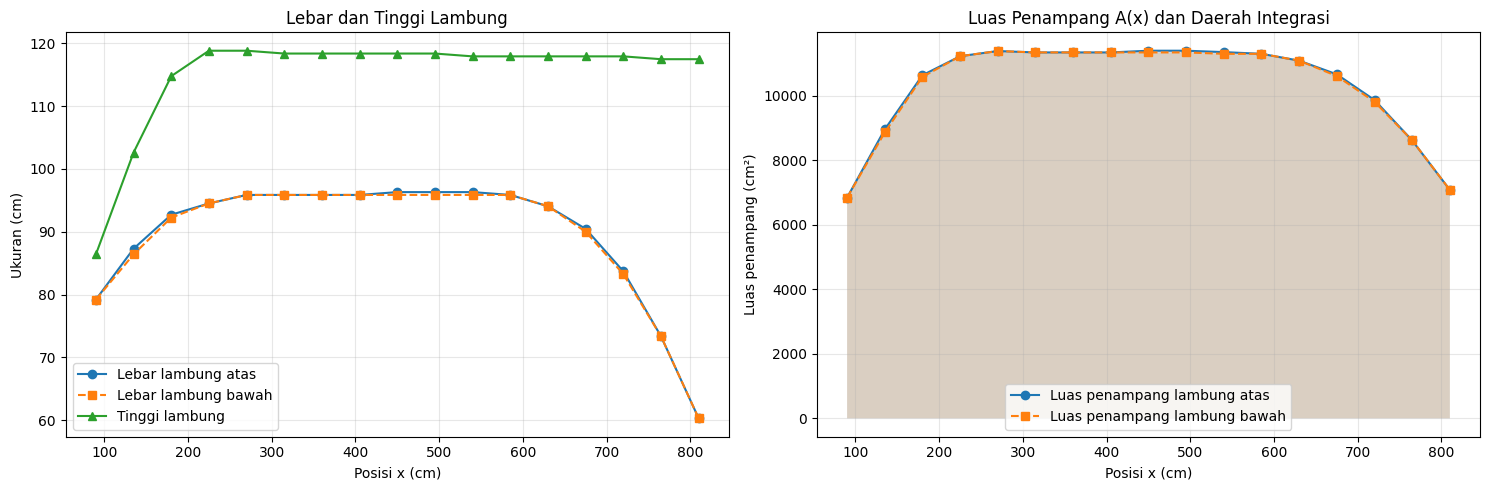

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Lebar dan tinggi
ax1.plot(x_cm, w_atas_cm, "o-", label="Lebar lambung atas")
ax1.plot(x_cm, w_bawah_cm, "s--", label="Lebar lambung bawah")
ax1.plot(x_cm, d_cm, "^-", label="Tinggi lambung")
ax1.set_xlabel("Posisi x (cm)")
ax1.set_ylabel("Ukuran (cm)")
ax1.set_title("Lebar dan Tinggi Lambung")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Luas penampang dan integrasi trapesium
ax2.plot(x_cm, A_atas, "o-", label="Luas penampang lambung atas")
ax2.plot(x_cm, A_bawah, "s--", label="Luas penampang lambung bawah")
ax2.fill_between(x_cm, A_atas, alpha=0.2)
ax2.fill_between(x_cm, A_bawah, alpha=0.2)
ax2.set_xlabel("Posisi x (cm)")
ax2.set_ylabel("Luas penampang (cm²)")
ax2.set_title("Luas Penampang A(x) dan Daerah Integrasi")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="lower center")

plt.tight_layout()
plt.show()

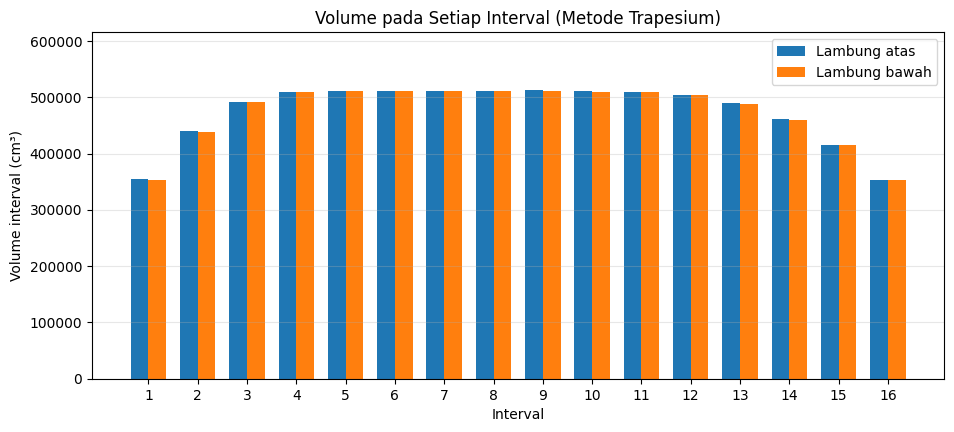

In [12]:
interval = np.arange(1, len(dV_atas) + 1)

plt.figure(figsize=(11, 4.5))
plt.bar(interval - 0.18, dV_atas, width=0.36, label="Lambung atas")
plt.bar(interval + 0.18, dV_bawah, width=0.36, label="Lambung bawah")
plt.xlabel("Interval")
plt.ylabel("Volume interval (cm³)")
plt.title("Volume pada Setiap Interval (Metode Trapesium)")
plt.ylim(0, max(dV_atas.max(), dV_bawah.max()) * 1.2)
plt.xticks(interval)
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.show()

## Kesimpulan

Berdasarkan perhitungan yang telah dilakukan, volume kedua lambung kapal ditentukan menggunakan metode integrasi numerik Simpson 1/3, dengan metode trapesium sebagai pembanding. Skala yang digunakan adalah 1 kotak grid = 45 cm. Lebar lambung (tampak atas) dan tinggi lambung (tampak samping) dibaca pada 17 titik, yaitu setiap 1 kotak (45 cm) dari $x = 2$ sampai $x = 18$, sehingga diperoleh 16 interval dengan panjang daerah hitung 720 cm. Bagian *reserve buoyancy* tidak ikut dihitung. Pada setiap titik, luas penampang dihitung dengan pendekatan persegi panjang, yaitu $A(x) = w(x) \times d(x)$.

Hasil perhitungan luas penampang kemudian diintegrasikan sepanjang lambung. Dengan metode Simpson 1/3, volume lambung atas adalah **7.612.035,75 cm³** dan volume lambung bawah adalah **7.593.786,45 cm³**. Volume total kedua lambung adalah **15.205.822,20 cm³**, atau setara dengan **15,2058 m³** (**15.205,8 liter**).

| Metode | Lambung atas | Lambung bawah | Kedua lambung |
|---|---|---|---|
| Trapesium | 7,5999 m³ | 7,5815 m³ | 15,1813 m³ |
| Simpson 1/3 | 7,6120 m³ | 7,5938 m³ | 15,2058 m³ |

Kedua metode memberikan hasil yang hampir sama, dengan selisih sekitar 0,16%. Artinya, hasil perhitungan ini konsisten dan jarak antar titik 1 kotak sudah cukup untuk bentuk lambung pada gambar. Lebar lambung atas dan bawah juga hampir sama (selisihnya paling besar 0,02 kotak, kurang dari 1 cm), sehingga anggapan bahwa kedua lambung identik sesuai dengan gambar.

Perlu diingat bahwa hasil ini bergantung pada pembacaan lebar dan tinggi lambung dari gambar (mengikuti garis luar lambung, ketelitian sekitar 1 piksel), pada skala 1 kotak = 45 cm, serta pada anggapan bahwa lantai kapal datar dan tampak depannya berbentuk persegi panjang.